# CheXpert Dataset – Label-Exploration

Auswertung: Wie oft kommt jedes Label vor (positiv, negativ, unsicher, fehlend)?

Nutzt Train- und Valid-CSV von CheXpert-small.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Projektroot: entweder aktuelles Verzeichnis oder Parent (wenn du in notebooks/ startest)
ROOT = Path.cwd()
if (ROOT / "CheXpert-v1.0-small").exists() and (ROOT / "src").exists():
    pass
else:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.dataset import ALL_LABELS

In [2]:
DATA_DIR = ROOT / "CheXpert-v1.0-small"
train_df = pd.read_csv(DATA_DIR / "train.csv")
valid_df = pd.read_csv(DATA_DIR / "valid.csv")

print(f"Train: {len(train_df):,} Zeilen")
print(f"Valid: {len(valid_df):,} Zeilen")
print(f"\nSpalten: {list(train_df.columns)}")

Train: 223,414 Zeilen
Valid: 234 Zeilen

Spalten: ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']


## Label-Verteilung pro Befund

Für jede der 14 Pathologie-Spalten: Anzahl **positiv (1)**, **negativ (0)**, **unsicher (-1)** und **fehlend (NaN)**.

In [3]:
def count_label_values(df: pd.DataFrame, label_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in label_cols:
        if col not in df.columns:
            continue
        s = df[col]
        rows.append({
            "label": col,
            "positive (1)": (s == 1.0).sum(),
            "negative (0)": (s == 0.0).sum(),
            "uncertain (-1)": (s == -1.0).sum(),
            "missing (NaN)": s.isna().sum(),
        })
    return pd.DataFrame(rows)

train_counts = count_label_values(train_df, ALL_LABELS)
valid_counts = count_label_values(valid_df, ALL_LABELS)

print("=== Train ===")
display(train_counts)
print("\n=== Valid ===")
display(valid_counts)

=== Train ===


,label,positive (1),negative (0),uncertain (-1),missing (NaN)
0,No Finding,22381,0,0,201033
1,Enlarged Cardiomediastinum,10798,21638,12403,178575
2,Cardiomegaly,27000,11116,8087,177211
3,Lung Opacity,105581,6599,5598,105636
4,Lung Lesion,9186,1270,1488,211470
5,Edema,52246,20726,12984,137458
6,Consolidation,14783,28097,27742,152792
7,Pneumonia,6039,2799,18770,195806
8,Atelectasis,33376,1328,33739,154971
9,Pneumothorax,19448,56341,3145,144480



=== Valid ===


,label,positive (1),negative (0),uncertain (-1),missing (NaN)
0,No Finding,38,196,0,0
1,Enlarged Cardiomediastinum,109,125,0,0
2,Cardiomegaly,68,166,0,0
3,Lung Opacity,126,108,0,0
4,Lung Lesion,1,233,0,0
5,Edema,45,189,0,0
6,Consolidation,33,201,0,0
7,Pneumonia,8,226,0,0
8,Atelectasis,80,154,0,0
9,Pneumothorax,8,226,0,0


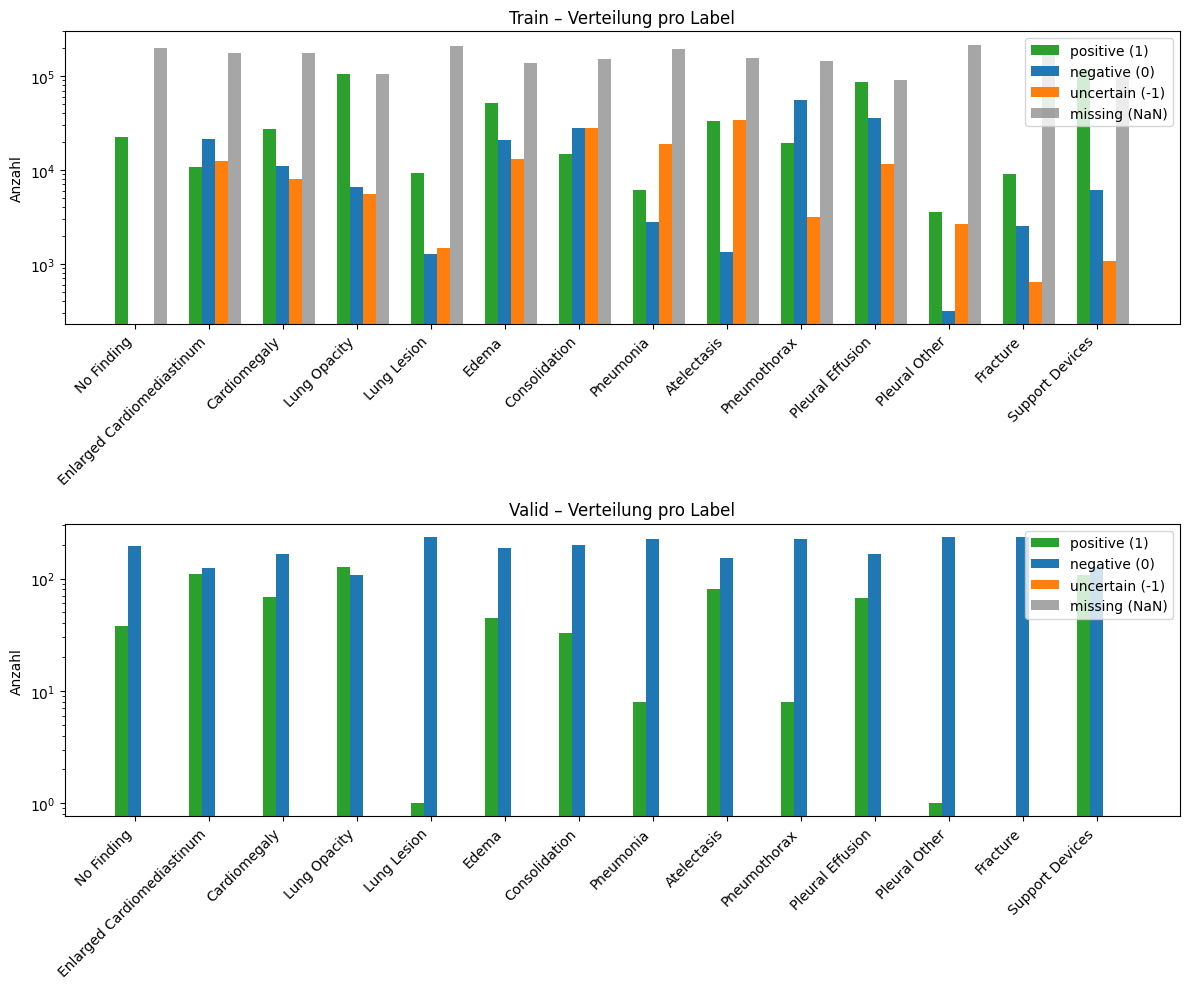

In [5]:
def plot_label_distribution(counts_df: pd.DataFrame, title: str, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    
    x = range(len(counts_df))
    width = 0.7
    
    ax.bar([i - width/4 for i in x], counts_df["positive (1)"], width/4, label="positive (1)", color="C2")
    ax.bar([i       for i in x], counts_df["negative (0)"], width/4, label="negative (0)", color="C0")
    ax.bar([i + width/4 for i in x], counts_df["uncertain (-1)"], width/4, label="uncertain (-1)", color="C1")
    ax.bar([i + width/2 for i in x], counts_df["missing (NaN)"], width/4, label="missing (NaN)", color="gray", alpha=0.7)
    
    ax.set_xticks(x)
    ax.set_xticklabels(counts_df["label"], rotation=45, ha="right")
    ax.set_ylabel("Anzahl")
    ax.set_title(title)
    ax.legend(loc="upper right")
    ax.set_yscale("log")
    return ax

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_label_distribution(train_counts, "Train – Verteilung pro Label", ax1)
plot_label_distribution(valid_counts, "Valid – Verteilung pro Label", ax2)
plt.tight_layout()
plt.show()

## Anteile (in % der Zeilen)

Pro Label: Welcher Anteil ist positiv/negativ/unsicher/fehlend?

In [6]:
n_train = len(train_df)
n_valid = len(valid_df)

train_pct = train_counts.copy()
for c in ["positive (1)", "negative (0)", "uncertain (-1)", "missing (NaN)"]:
    train_pct[c + " %"] = (train_counts[c] / n_train * 100).round(2)

valid_pct = valid_counts.copy()
for c in ["positive (1)", "negative (0)", "uncertain (-1)", "missing (NaN)"]:
    valid_pct[c + " %"] = (valid_counts[c] / n_valid * 100).round(2)

print("Train (Anteile in %)")
display(train_pct)
print("\nValid (Anteile in %)")
display(valid_pct)

Train (Anteile in %)


,label,positive (1),negative (0),uncertain (-1),missing (NaN),positive (1) %,negative (0) %,uncertain (-1) %,missing (NaN) %
0,No Finding,22381,0,0,201033,10.02,0.00,0.00,89.98
1,Enlarged Cardiomediastinum,10798,21638,12403,178575,4.83,9.69,5.55,79.93
2,Cardiomegaly,27000,11116,8087,177211,12.09,4.98,3.62,79.32
3,Lung Opacity,105581,6599,5598,105636,47.26,2.95,2.51,47.28
4,Lung Lesion,9186,1270,1488,211470,4.11,0.57,0.67,94.65
5,Edema,52246,20726,12984,137458,23.39,9.28,5.81,61.53
6,Consolidation,14783,28097,27742,152792,6.62,12.58,12.42,68.39
7,Pneumonia,6039,2799,18770,195806,2.70,1.25,8.40,87.64
8,Atelectasis,33376,1328,33739,154971,14.94,0.59,15.10,69.36
9,Pneumothorax,19448,56341,3145,144480,8.70,25.22,1.41,64.67



Valid (Anteile in %)


,label,positive (1),negative (0),uncertain (-1),missing (NaN),positive (1) %,negative (0) %,uncertain (-1) %,missing (NaN) %
0,No Finding,38,196,0,0,16.24,83.76,0.0,0.0
1,Enlarged Cardiomediastinum,109,125,0,0,46.58,53.42,0.0,0.0
2,Cardiomegaly,68,166,0,0,29.06,70.94,0.0,0.0
3,Lung Opacity,126,108,0,0,53.85,46.15,0.0,0.0
4,Lung Lesion,1,233,0,0,0.43,99.57,0.0,0.0
5,Edema,45,189,0,0,19.23,80.77,0.0,0.0
6,Consolidation,33,201,0,0,14.10,85.90,0.0,0.0
7,Pneumonia,8,226,0,0,3.42,96.58,0.0,0.0
8,Atelectasis,80,154,0,0,34.19,65.81,0.0,0.0
9,Pneumothorax,8,226,0,0,3.42,96.58,0.0,0.0


## Frontal vs. Lateral

CheXpert enthält Frontal- und Lateralaufnahmen. Oft trainiert man nur auf Frontal.

In [7]:
if "Frontal/Lateral" in train_df.columns:
    print("Train:")
    print(train_df["Frontal/Lateral"].value_counts())
    print("\nValid:")
    print(valid_df["Frontal/Lateral"].value_counts())
else:
    print("Spalte 'Frontal/Lateral' nicht gefunden.")

Train:
Frontal/Lateral
Frontal    191027
Lateral     32387
Name: count, dtype: int64

Valid:
Frontal/Lateral
Frontal    202
Lateral     32
Name: count, dtype: int64
